In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from multiprocessing import Pool
from concurrent.futures import ProcessPoolExecutor
import concurrent.futures
import pandas as pd
from tqdm import tqdm
from scipy.optimize import minimize, basinhopping

#plt.rcParams['text.latex.preamble'] = r"\usepackage{amsmath}"
#plt.rc('font',**{'family':'sans-serif','sans-serif':['Helvetica']})
#plt.rc('text',usetex=True)

import julia
from julia import Main
from julia import Distributed
Main.eval("using QuadGK")

In [2]:
Main.eval("""
    using CSV
    using DataFrames 
    df_splitting_moments = CSV.read("splitting_moments_grid.csv", DataFrame)
    df_hard_moments = CSV.read("../NP hard grid/hard_moments_grid.csv", DataFrame)          
""")

Main.include("..\\core\\constants.jl")
Main.include("moments.jl")
Main.include("..\\initialization_old.jl")
Main.include("jet.jl")

Main.include("../core/alpha_s.jl")
Main.include("../core/constants.jl")
Main.include("../core/setting.jl")

In [5]:
import numpy as np
from tqdm import tqdm

# parameters
N = 10**4
bmin, bmax     = 1e-5, 3.0
a1min, a1max   = 2.0, 2.5
a2min, a2max   = 1.0, 1.15
tol = 1e-5

# draw random points
b_rand  = np.random.uniform(bmin, bmax, N)
a1_rand = np.random.uniform(a1min, a1max, N)
a2_rand = np.random.uniform(a2min, a2max, N)

errors = []
points = []

build = Main.buildgrid_func
split = Main.splitting_moments_func

for b, a1, a2 in tqdm(zip(b_rand, a1_rand, a2_rand),
                      total=N,
                      desc="Testing random points"):

    # 1) call Julia functions and cast to np.array
    num    = np.array(build(a1b=a1*b, a2=a2), dtype=float)
    interp = np.array(split(a1b=a1*b, a2=a2), dtype=float)

    # 2) mask away tiny denominators
    valid = np.abs(num) >= tol
    if not valid.any():
        continue

    # 3) compute the max relative error
    rel_err = np.abs((interp[valid] - num[valid]) / num[valid])
    e_pt    = rel_err.max()

    # 4) record
    errors.append(e_pt)
    points.append((b, a1, a2))

# --- outside the loop ---
errors = np.array(errors)
imax     = np.argmax(errors)
max_err  = errors[imax]
max_point = points[imax]

q99 = np.quantile(errors, 0.99)
q90 = np.quantile(errors, 0.90)
q50 = np.quantile(errors, 0.50)

print(f"Tested {len(errors)} points (excluded small‑num).")
print(f"Max rel‑error: {max_err:.3e} at b,a1,a2 = {max_point}")
print(f"99%-ile error: {q99:.3e}")
print(f"90%-ile error: {q90:.3e}")
print(f"50%-ile error: {q50:.3e}")

Testing random points: 100%|██████████| 10000/10000 [00:26<00:00, 383.89it/s]

Tested 10000 points (excluded small‑num).
Max rel‑error: 6.726e-02 at b,a1,a2 = (np.float64(1.0757126656077343), np.float64(2.293068958351438), np.float64(1.1211193076533048))
99%-ile error: 4.686e-04
90%-ile error: 4.343e-05
50%-ile error: 1.038e-05


In [17]:
b,a1,a2 = np.float64(1.965562356169221), np.float64(3.5185292538059887), np.float64(0.7489630602951446)
display((split(b=b,a1=a1,a2=a2)-build(a1b=a1*b,a2=a2))/build(a1b=a1*b,a2=a2))
display(build(a1b=a1*b,a2=a2))
display(split(b=b,a1=a1,a2=a2))

a1*b

array([ 4.85261748e-05,  9.73036800e-05,  1.15572781e-04,  4.78794785e-05,
        1.02736408e-04,  1.39370967e-04,  1.77492705e-04,  1.08704870e-04,
        1.49008416e-04,  1.94246036e-04,  2.51107685e-04,  1.67880719e-04,
        4.66184421e-05,  1.93549878e-04,  1.18757372e-04, -4.66544251e-01,
        9.43365382e-05,  1.47942884e-04,  1.65808500e-04,  1.10904263e-04,
        2.69176416e-05,  6.06889260e-05,  1.01429008e-04,  8.36185575e-05])

(0.131950016997533,
 -0.017304116030598993,
 -0.006941975645062957,
 0.3105532670425016,
 0.010906037259567642,
 0.0021129156143519603,
 0.001197463405054032,
 0.025965127126802295,
 -0.0015146891931502025,
 -0.0005146116331226701,
 -0.00038693925295437364,
 -0.003969897023861695,
 0.7489822921099399,
 0.055528268518684885,
 -0.23370674613172254,
 0.00010297444847112041,
 0.07094138836694641,
 -0.027042250909534042,
 0.044339681986835924,
 0.21355088166130604,
 1.8914143248020128,
 -2.5000732238587897,
 -4.492845572848026,
 -11.7402042955267)

array([ 1.31956420e-01, -1.73057998e-02, -6.94277795e-03,  3.10568136e-01,
        1.09071577e-02,  2.11321009e-03,  1.19767595e-03,  2.59679497e-02,
       -1.51491489e-03, -5.14711594e-04, -3.87036416e-04, -3.97056349e-03,
        7.49017208e-01,  5.55390160e-02, -2.33734501e-01,  5.49323116e-05,
        7.09480807e-02, -2.70462516e-02,  4.43470339e-02,  2.13574565e-01,
        1.89146524e+00, -2.50022495e+00, -4.49330128e+00, -1.17411860e+01])

np.float64(6.9158886503612305)

In [23]:
Na1b = 2500 
Na2 = 400                  

eps = 1e-4                  
log_vals = np.logspace(np.log10(eps), np.log10(25), Na1b-1)
a1b_vals = np.concatenate(([0.0], log_vals))   

a2_vals  = np.linspace(0.5, 2.0, Na2)

A1B, A2  = np.meshgrid(a1b_vals, a2_vals, indexing="ij")
params   = np.column_stack((A1B.ravel(), A2.ravel()))     

out = np.empty((params.shape[0], 24), dtype=np.float64)

for i, (a1b, a2) in tqdm(enumerate(params),
                         total=params.shape[0],
                         desc="Filling moments grid",
                         unit="row"):
    out[i, :] = Main.buildgrid_func(a1b=a1b, a2=a2)

cols = ["γqq0","γqg0","γgq0","γgg0",
        "dγqq0","dγqg0","dγgq0","dγgg0",
        "ddγqq0","ddγqg0","ddγgq0","ddγgg0",
        "γqq1","γqg1","γgq1","γgg1",
        "dγqq1","dγqg1","dγgq1","dγgg1",
        "γqq2","γqg2","γgq2","γgg2"]

df = pd.DataFrame(out, columns=cols)
df.insert(0, "a1b", params[:, 0])
df.insert(1, "a2",  params[:, 1])
df.to_csv("moments_grid_log_a1b.csv", index=False)

Filling moments grid:   0%|          | 453/1000000 [00:01<1:02:36, 266.09row/s]


KeyboardInterrupt: 

Pert

In [5]:
a_s = 0.118/(4*np.pi)
μ = 91.2

a1 = 0.0
a2 = 1.0

b_array = np.linspace(0.0001,2,100)

b0 = 1.122918967

Jq_pert_LL=[]
Jq_pert_NLL=[]
Jq_pert_NNLL=[]

Jg_pert_LL=[]
Jg_pert_NLL=[]
Jg_pert_NNLL=[]

Jq_NP_LL=[]
Jq_NP_NLL=[]
Jq_NP_NNLL=[]

Jg_NP_LL=[]
Jg_NP_NLL=[]
Jg_NP_NNLL=[]

for b in b_array:

    Lb = 2*np.log(b*μ/b0)

    # Pert

    Jq_pert_LL.append(Main.Jq_func(a_s=a_s, Lb=Lb, order=0))
    Jq_pert_NLL.append(Main.Jq_func(a_s=a_s, Lb=Lb, order=1))
    Jq_pert_NNLL.append(Main.Jq_func(a_s=a_s, Lb=Lb, order=2))

    Jg_pert_LL.append(Main.Jg_func(a_s=a_s, Lb=Lb, order=0))
    Jg_pert_NLL.append(Main.Jg_func(a_s=a_s, Lb=Lb, order=1))
    Jg_pert_NNLL.append(Main.Jg_func(a_s=a_s, Lb=Lb, order=2))

    Main.init_splitting_globals(b=b, a1=a1, a2=a2)

    Jq_NP_LL.append(Main.Jq_NP_func(a_s=a_s, Lb=Lb, order=0))
    Jq_NP_NLL.append(Main.Jq_NP_func(a_s=a_s, Lb=Lb, order=1))
    Jq_NP_NNLL.append(Main.Jq_NP_func(a_s=a_s, Lb=Lb, order=2))

    Jg_NP_LL.append(Main.Jg_NP_func(a_s=a_s, Lb=Lb, order=0))
    Jg_NP_NLL.append(Main.Jg_NP_func(a_s=a_s, Lb=Lb, order=1))
    Jg_NP_NNLL.append(Main.Jg_NP_func(a_s=a_s, Lb=Lb, order=2))   

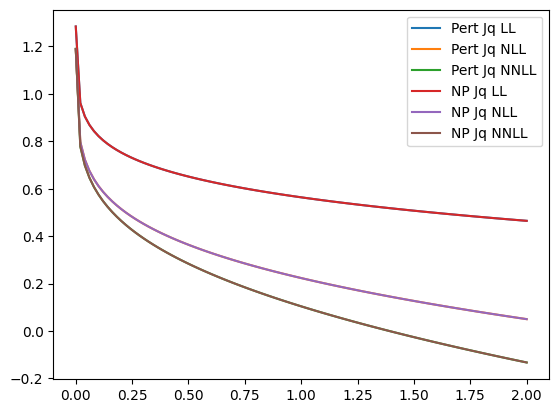

In [6]:
plt.plot(b_array,Jq_pert_LL,label="Pert Jq LL")
plt.plot(b_array,Jq_pert_NLL,label="Pert Jq NLL")
plt.plot(b_array,Jq_pert_NNLL,label="Pert Jq NNLL")

plt.plot(b_array,Jq_NP_LL,label="NP Jq LL")
plt.plot(b_array,Jq_NP_NLL,label="NP Jq NLL")
plt.plot(b_array,Jq_NP_NNLL,label="NP Jq NNLL")

plt.legend()

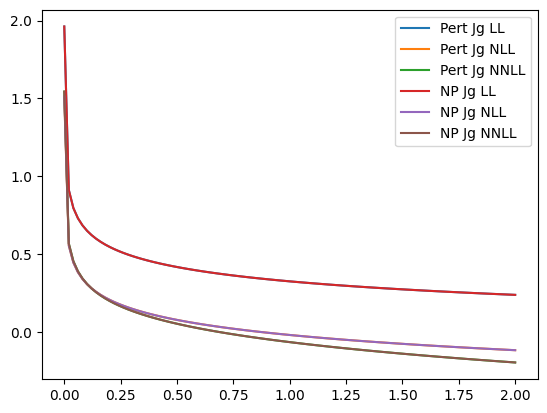

In [7]:
plt.plot(b_array,Jg_pert_LL,label="Pert Jg LL")
plt.plot(b_array,Jg_pert_NLL,label="Pert Jg NLL")
plt.plot(b_array,Jg_pert_NNLL,label="Pert Jg NNLL")

plt.plot(b_array,Jg_NP_LL,label="NP Jg LL")
plt.plot(b_array,Jg_NP_NLL,label="NP Jg NLL")
plt.plot(b_array,Jg_NP_NNLL,label="NP Jg NNLL")

plt.legend()

NP

In [20]:
a_s = 0.118/(4*np.pi)
μ = 91.2

a1_old = 2.45
a1 = a1_old
a2 = 1.13

b_array = np.linspace(0.01,2,100)

b0 = 1.122918967

Jq_pert_LL=[]
Jq_pert_NLL=[]
Jq_pert_NNLL=[]

Jg_pert_LL=[]
Jg_pert_NLL=[]
Jg_pert_NNLL=[]

Jq_NP_LL=[]
Jq_NP_NLL=[]
Jq_NP_NNLL=[]

Jg_NP_LL=[]
Jg_NP_NLL=[]
Jg_NP_NNLL=[]

for b in b_array:

    bstar = b/np.sqrt(1+b**2/b0**2)
    Lb = 2*np.log(bstar*μ/b0)
    FNP = np.exp(-(a1_old*b)**a2)
    # Pert

    Jq_pert_LL.append(Main.Jq_func(a_s=a_s, Lb=Lb, order=0)*FNP)
    Jq_pert_NLL.append(Main.Jq_func(a_s=a_s, Lb=Lb, order=1)*FNP)
    Jq_pert_NNLL.append(Main.Jq_func(a_s=a_s, Lb=Lb, order=2)*FNP)

    Jg_pert_LL.append(Main.Jg_func(a_s=a_s, Lb=Lb, order=0)*FNP)
    Jg_pert_NLL.append(Main.Jg_func(a_s=a_s, Lb=Lb, order=1)*FNP)
    Jg_pert_NNLL.append(Main.Jg_func(a_s=a_s, Lb=Lb, order=2)*FNP)

    Main.init_splitting_globals(b=b, a1=a1, a2=a2)

    Jq_NP_LL.append(Main.Jq_NP_func(a_s=a_s, Lb=Lb, order=0))
    Jq_NP_NLL.append(Main.Jq_NP_func(a_s=a_s, Lb=Lb, order=1))
    Jq_NP_NNLL.append(Main.Jq_NP_func(a_s=a_s, Lb=Lb, order=2))

    Jg_NP_LL.append(Main.Jg_NP_func(a_s=a_s, Lb=Lb, order=0))
    Jg_NP_NLL.append(Main.Jg_NP_func(a_s=a_s, Lb=Lb, order=1))
    Jg_NP_NNLL.append(Main.Jg_NP_func(a_s=a_s, Lb=Lb, order=2)) 

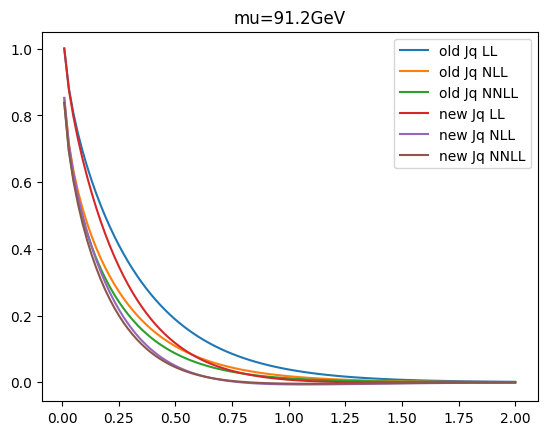

In [21]:
plt.plot(b_array,Jq_pert_LL,label="old Jq LL")
plt.plot(b_array,Jq_pert_NLL,label="old Jq NLL")
plt.plot(b_array,Jq_pert_NNLL,label="old Jq NNLL")

plt.plot(b_array,Jq_NP_LL,label="new Jq LL")
plt.plot(b_array,Jq_NP_NLL,label="new Jq NLL")
plt.plot(b_array,Jq_NP_NNLL,label="new Jq NNLL")

plt.title("mu=91.2GeV")
plt.legend()

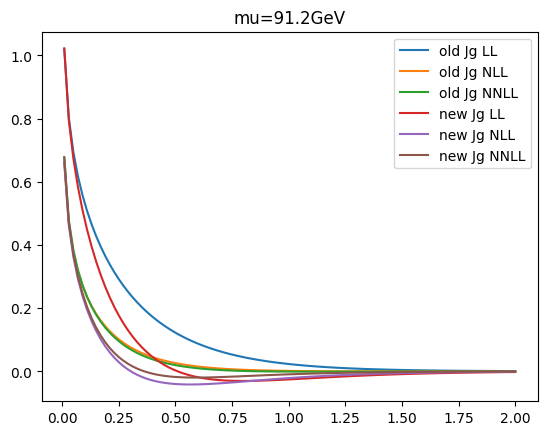

In [22]:
plt.plot(b_array,Jg_pert_LL,label="old Jg LL")
plt.plot(b_array,Jg_pert_NLL,label="old Jg NLL")
plt.plot(b_array,Jg_pert_NNLL,label="old Jg NNLL")

plt.plot(b_array,Jg_NP_LL,label="new Jg LL")
plt.plot(b_array,Jg_NP_NLL,label="new Jg NLL")
plt.plot(b_array,Jg_NP_NNLL,label="new Jg NNLL")

plt.title("mu=91.2GeV")
plt.legend()

In [26]:
μ = 29.0

Main.order=2
Main.αs_Z=0.118
a_s = Main.alpha_s_func(μ)/(4*np.pi)

a1_old = 2.45
a1 = a1_old
a2 = 1.13

b_array = np.linspace(0.01,2,100)

b0 = 1.122918967

Jq_pert_LL=[]
Jq_pert_NLL=[]
Jq_pert_NNLL=[]

Jg_pert_LL=[]
Jg_pert_NLL=[]
Jg_pert_NNLL=[]

Jq_NP_LL=[]
Jq_NP_NLL=[]
Jq_NP_NNLL=[]

Jg_NP_LL=[]
Jg_NP_NLL=[]
Jg_NP_NNLL=[]

for b in b_array:

    bstar = b/np.sqrt(1+b**2/b0**2)
    Lb = 2*np.log(bstar*μ/b0)
    FNP = np.exp(-(a1_old*b)**a2)
    # Pert

    Jq_pert_LL.append(Main.Jq_func(a_s=a_s, Lb=Lb, order=0)*FNP)
    Jq_pert_NLL.append(Main.Jq_func(a_s=a_s, Lb=Lb, order=1)*FNP)
    Jq_pert_NNLL.append(Main.Jq_func(a_s=a_s, Lb=Lb, order=2)*FNP)

    Jg_pert_LL.append(Main.Jg_func(a_s=a_s, Lb=Lb, order=0)*FNP)
    Jg_pert_NLL.append(Main.Jg_func(a_s=a_s, Lb=Lb, order=1)*FNP)
    Jg_pert_NNLL.append(Main.Jg_func(a_s=a_s, Lb=Lb, order=2)*FNP)

    Main.init_splitting_globals(b=b, a1=a1, a2=a2)

    Jq_NP_LL.append(Main.Jq_NP_func(a_s=a_s, Lb=Lb, order=0))
    Jq_NP_NLL.append(Main.Jq_NP_func(a_s=a_s, Lb=Lb, order=1))
    Jq_NP_NNLL.append(Main.Jq_NP_func(a_s=a_s, Lb=Lb, order=2))

    Jg_NP_LL.append(Main.Jg_NP_func(a_s=a_s, Lb=Lb, order=0))
    Jg_NP_NLL.append(Main.Jg_NP_func(a_s=a_s, Lb=Lb, order=1))
    Jg_NP_NNLL.append(Main.Jg_NP_func(a_s=a_s, Lb=Lb, order=2)) 

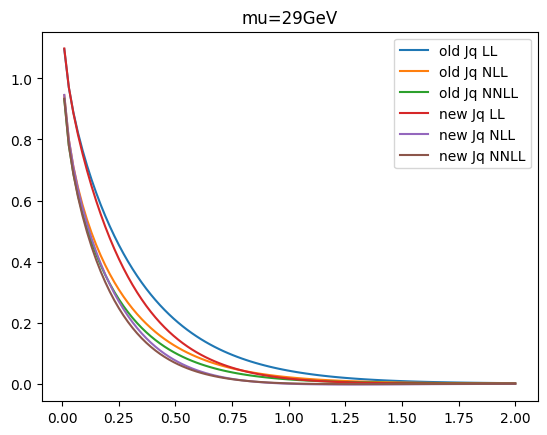

In [27]:
plt.plot(b_array,Jq_pert_LL,label="old Jq LL")
plt.plot(b_array,Jq_pert_NLL,label="old Jq NLL")
plt.plot(b_array,Jq_pert_NNLL,label="old Jq NNLL")

plt.plot(b_array,Jq_NP_LL,label="new Jq LL")
plt.plot(b_array,Jq_NP_NLL,label="new Jq NLL")
plt.plot(b_array,Jq_NP_NNLL,label="new Jq NNLL")

plt.title("mu=29GeV")
plt.legend()

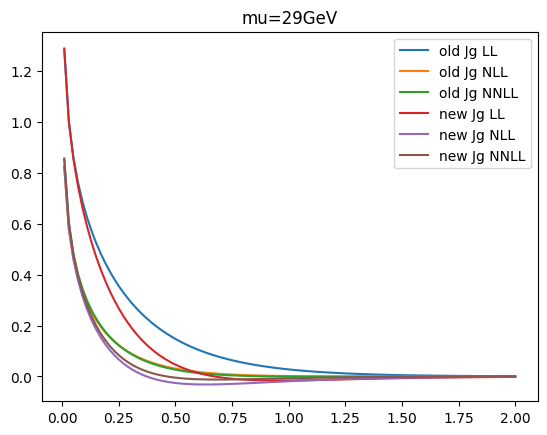

In [28]:
plt.plot(b_array,Jg_pert_LL,label="old Jg LL")
plt.plot(b_array,Jg_pert_NLL,label="old Jg NLL")
plt.plot(b_array,Jg_pert_NNLL,label="old Jg NNLL")

plt.plot(b_array,Jg_NP_LL,label="new Jg LL")
plt.plot(b_array,Jg_NP_NLL,label="new Jg NLL")
plt.plot(b_array,Jg_NP_NNLL,label="new Jg NNLL")

plt.title("mu=29GeV")
plt.legend()